In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import yfinance as yf
from datetime import date, timedelta

In [36]:
from sklearn.preprocessing import MinMaxScaler
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Dropout,LSTM
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
start = "2010-01-01"
today = date.today()
yesterday = today - timedelta(days=1)
end = yesterday.strftime('%Y-%m-%d')

In [4]:
data = yf.download("AAPL",start,end)

[*********************100%***********************]  1 of 1 completed


In [5]:
data = data.reset_index()

In [6]:
data = data.drop(columns="Date",axis=1)

In [7]:
data.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
0,6.412384,6.427065,6.363544,6.395005,493729600
1,6.423470,6.459726,6.389612,6.430063,601904800
2,6.321296,6.448938,6.314704,6.423470,552160000
3,6.309609,6.352157,6.263766,6.344666,477131200
4,6.351559,6.352158,6.264067,6.301221,447610800


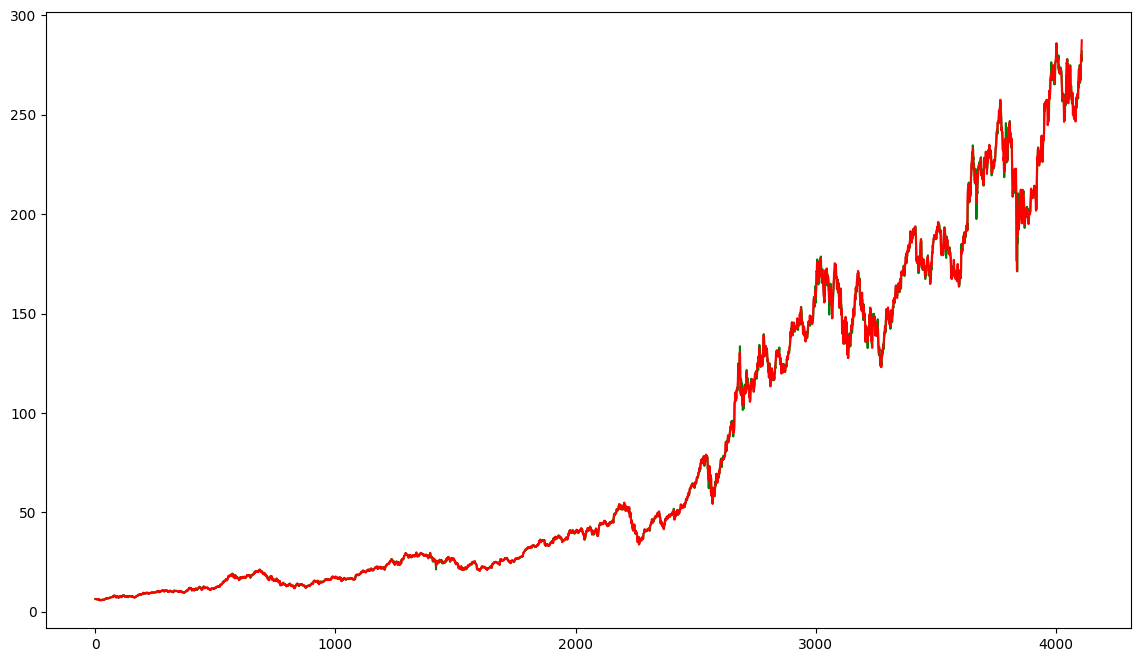

In [16]:
plt.figure(figsize=(14,8))
plt.plot(data.Open,"g",label="Open")
plt.plot(data.Close,"r",label="Close")
plt.show()

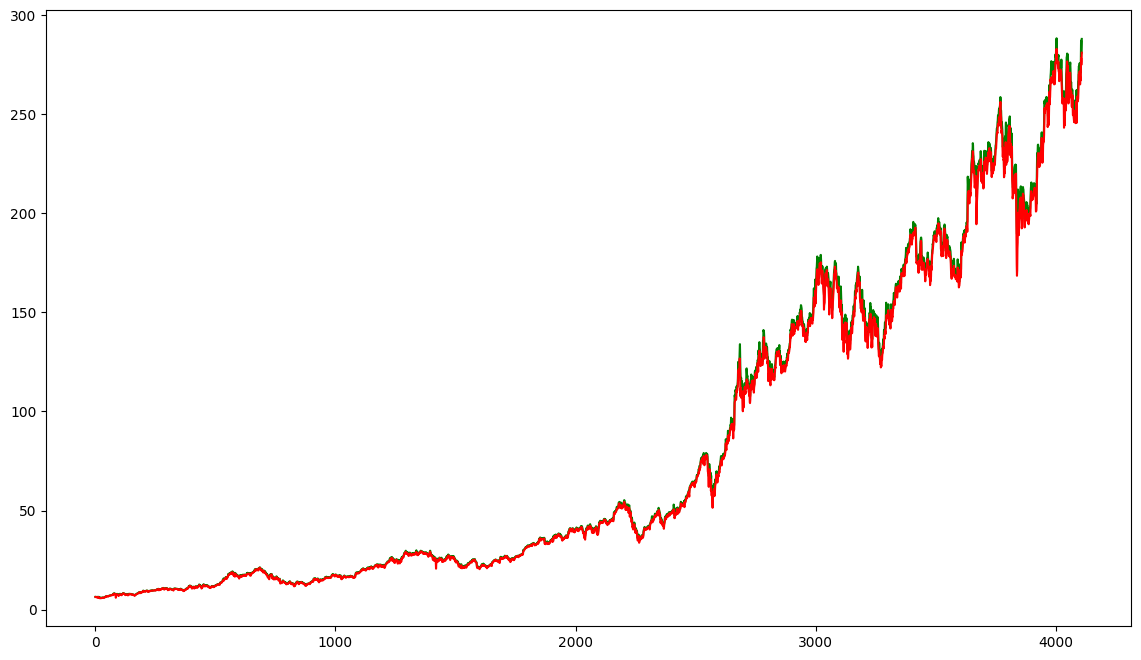

In [17]:
plt.figure(figsize=(14,8))
plt.plot(data.High,"g",label="High")
plt.plot(data.Low,"r",label="Low")
plt.show()

In [22]:
H_MA100 = data.High.rolling(100).mean()
H_MA200 = data.High.rolling(200).mean()

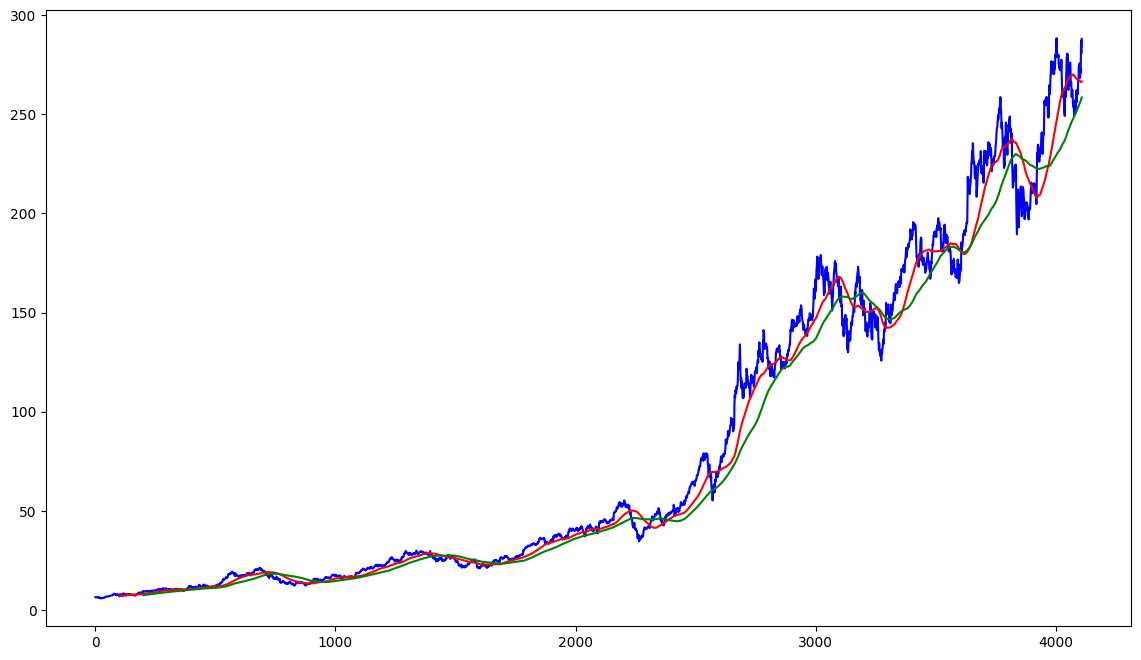

In [23]:
plt.figure(figsize=(14,8))
plt.plot(data.High,"b",label="High")
plt.plot(H_MA100,"r",label="MA100")
plt.plot(H_MA200,"g",label="MA200")
plt.show()

In [24]:
L_MA100 = data.Low.rolling(100).mean()
L_MA200 = data.Low.rolling(200).mean()

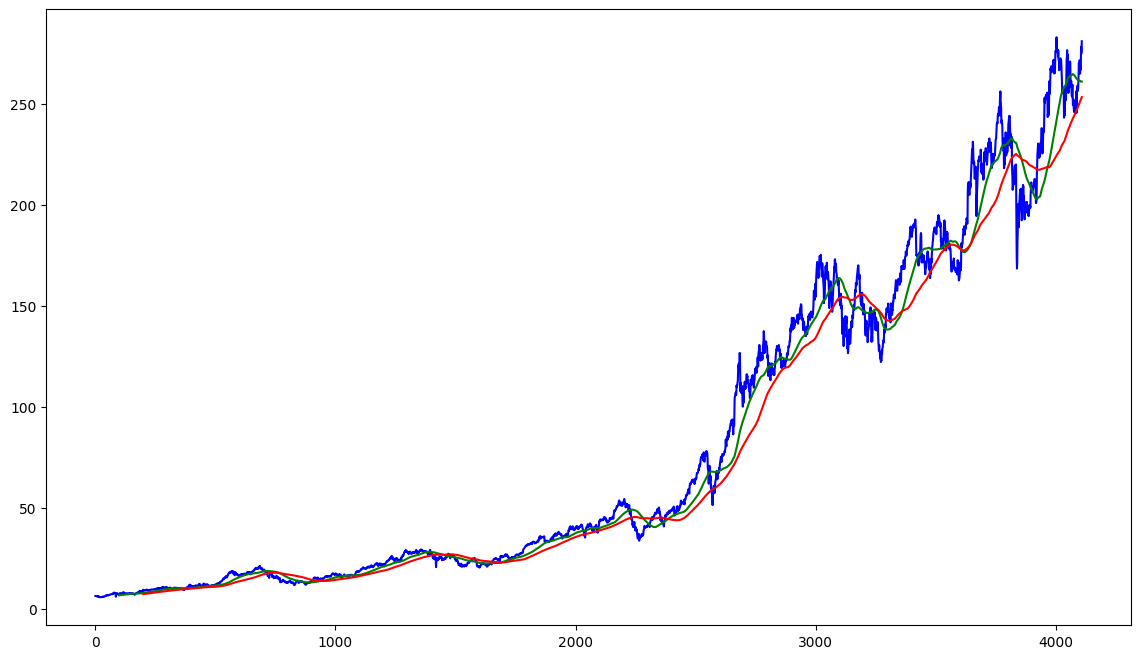

In [25]:
plt.figure(figsize=(14,8))
plt.plot(data.Low,"b",label="Low")
plt.plot(L_MA100,"g")
plt.plot(L_MA200,"r")
plt.show()

In [28]:
data_training = pd.DataFrame(
    data[["Open", "High", "Low", "Close"]][0:int(len(data)*0.70)]
)

data_testing = pd.DataFrame(
    data[["Open", "High", "Low", "Close"]][int(len(data)*0.70):int(len(data))]
)

print(data_training)
print(data_testing)

Price         Open        High         Low       Close
Ticker        AAPL        AAPL        AAPL        AAPL
0         6.395005    6.427065    6.363544    6.412384
1         6.430063    6.459726    6.389612    6.423470
2         6.423470    6.448938    6.314704    6.321296
3         6.344666    6.352157    6.263766    6.309609
4         6.301221    6.352158    6.264067    6.351559
...            ...         ...         ...         ...
2872    121.253765  122.190388  121.029369  122.014771
2873    121.644047  121.809906  120.131787  120.531807
2874    121.048880  123.087992  120.834235  122.824562
2875    123.097765  123.244114  121.790398  122.834343
2876    123.517279  125.331996  123.136776  123.653870

[2877 rows x 4 columns]
Price         Open        High         Low       Close
Ticker        AAPL        AAPL        AAPL        AAPL
2877    124.112417  124.639268  123.439216  124.034363
2878    123.927060  125.068577  122.873364  123.039223
2879    123.448991  124.336836  123.0294

In [37]:
Scaler = MinMaxScaler(feature_range=(-1,1))
data_training_scaled = Scaler.fit_transform(data_training)
data_testing_scaled = Scaler.fit_transform(data_testing)

In [32]:
print(data_training_scaled.shape)
print(data_testing_scaled.shape)

(2877, 4)
(1233, 4)


In [33]:
print(data_training_scaled)
print(data_testing_scaled)

[[-0.99057426 -0.99180209 -0.98993713 -0.99014064]
 [-0.99005059 -0.99131907 -0.98954152 -0.98997452]
 [-0.99014907 -0.99147861 -0.99067832 -0.99150551]
 ...
 [ 0.72204395  0.73352493  0.7472595   0.75419181]
 [ 0.75264875  0.73583386  0.76177013  0.75433837]
 [ 0.75891515  0.76671206  0.78220264  0.76661825]]
[[-0.99183393 -0.9963121  -0.98471634 -0.98789888]
 [-0.99411547 -0.99107706 -0.99175321 -1.        ]
 [-1.         -1.         -0.98981201 -0.98528856]
 ...
 [ 0.92279255  0.90585905  0.89833452  0.87012863]
 [ 0.889189    0.95390395  0.91872955  0.95950628]
 [ 0.95061089  0.99609553  0.97556163  1.        ]]


In [35]:
X_train =[]
y_train =[]

for i in range(100,data_training_scaled.shape[0]):
  X_train.append(data_training_scaled[i-100:i])
  y_train.append(data_training_scaled[i,0])

X_train,y_train = np.array(X_train),np.array(y_train)

print(X_train.shape,y_train.shape)
print(X_train)
print(y_train)

(2777, 100, 4) (2777,)
[[[-0.99057426 -0.99180209 -0.98993713 -0.99014064]
  [-0.99005059 -0.99131907 -0.98954152 -0.98997452]
  [-0.99014907 -0.99147861 -0.99067832 -0.99150551]
  ...
  [-0.97542412 -0.97567213 -0.97453134 -0.9754369 ]
  [-0.97897335 -0.97750672 -0.97866927 -0.97612833]
  [-0.97417099 -0.97512713 -0.97567274 -0.97662672]]

 [[-0.99005059 -0.99131907 -0.98954152 -0.98997452]
  [-0.99014907 -0.99147861 -0.99067832 -0.99150551]
  [-0.99132618 -0.99290993 -0.99145135 -0.99168063]
  ...
  [-0.97897335 -0.97750672 -0.97866927 -0.97612833]
  [-0.97417099 -0.97512713 -0.97567274 -0.97662672]
  [-0.97393823 -0.9743472  -0.97323543 -0.97247822]]

 [[-0.99014907 -0.99147861 -0.99067832 -0.99150551]
  [-0.99132618 -0.99290993 -0.99145135 -0.99168063]
  [-0.99197514 -0.99290991 -0.99144677 -0.99105205]
  ...
  [-0.97417099 -0.97512713 -0.97567274 -0.97662672]
  [-0.97393823 -0.9743472  -0.97323543 -0.97247822]
  [-0.9700041  -0.97190553 -0.97130742 -0.97089334]]

 ...

 [[ 0.79066

In [55]:
model = Sequential()

model.add(LSTM(units=70,activation="tanh",return_sequences=True,input_shape=(X_train.shape[1],4)))
model.add(Dropout(0.3))

model.add(LSTM(units=60,activation="tanh",return_sequences=True))
model.add(Dropout(0.3))

model.add(LSTM(units=50,activation="tanh"))
model.add(Dropout(0.3))

model.add(Dense(units=1))

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 100, 70)        │        21,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 100, 70)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 100, 60)        │        31,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ (None, 50)             │        22,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,691 (291.76 KB)

 Trainable params: 74,691 (291.76 KB)

 Non-trainable params: 0 (0.00 B)

In [56]:
early_stop = EarlyStopping(
    monitor = 'val_loss',
    patience = 3,
    restore_best_weights =True
)
model.compile(optimizer='adam',loss='mean_squared_error',metrics=['mae','mse'])
history = model.fit(X_train,y_train,epochs =15,validation_split = 0.2,callbacks=[early_stop])

Epoch 1/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 19s 193ms/step - loss: 0.0286 - mae: 0.1205 - mse: 0.0286 - val_loss: 0.0262 - val_mae: 0.1321 - val_mse: 0.0262
Epoch 2/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 13s 184ms/step - loss: 0.0081 - mae: 0.0708 - mse: 0.0081 - val_loss: 0.0205 - val_mae: 0.1088 - val_mse: 0.0205
Epoch 3/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 20s 180ms/step - loss: 0.0073 - mae: 0.0668 - mse: 0.0073 - val_loss: 0.0203 - val_mae: 0.1116 - val_mse: 0.0203
Epoch 4/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 14s 192ms/step - loss: 0.0067 - mae: 0.0640 - mse: 0.0067 - val_loss: 0.0182 - val_mae: 0.1010 - val_mse: 0.0182
Epoch 5/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 19s 177ms/step - loss: 0.0065 - mae: 0.0631 - mse: 0.0065 - val_loss: 0.0194 - val_mae: 0.1084 - val_mse: 0.0194
Epoch 6/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 21s 178ms/step - loss: 0.0066 - mae: 0.0636 - mse: 0.0066 - val_loss: 0.0142 - val_mae: 0.0904 - val_mse: 0.0142
Epoch 7/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 12s 167ms/step - loss: 0.0063 - mae: 0.0628 - mse: 0.006

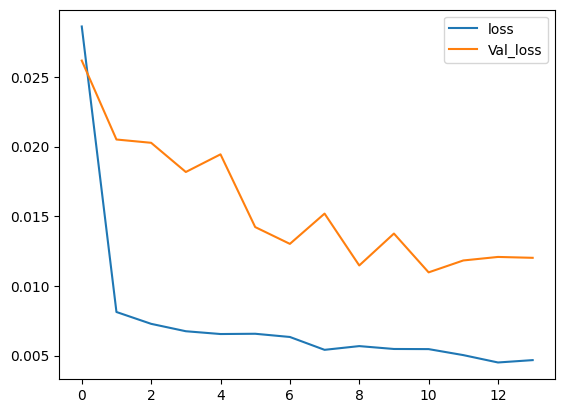

In [57]:
plt.plot(history.history["loss"],label="loss")
plt.plot(history.history["val_loss"],label="Val_loss")
plt.legend()

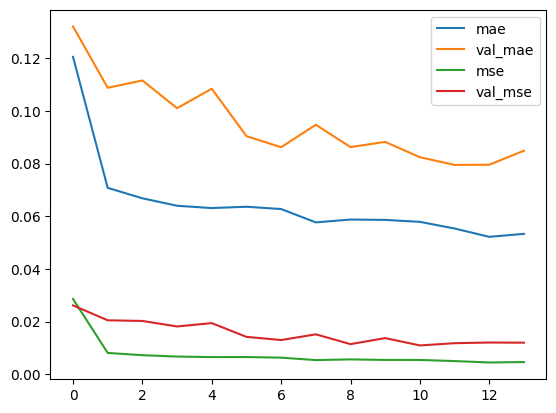

In [58]:
plt.plot(history.history["mae"],label="mae")
plt.plot(history.history["val_mae"],label="val_mae")
plt.plot(history.history["mse"],label="mse")
plt.plot(history.history["val_mse"],label="val_mse")
plt.legend()

In [59]:
model.save("Stock_predictor.h5")

In [60]:
data_testing.head()

Price,Open,High,Low,Close
Ticker,AAPL,AAPL,AAPL,AAPL
2877,124.112417,124.639268,123.439216,124.034363
2878,123.927060,125.068577,122.873364,123.039223
2879,123.448991,124.336836,123.029461,124.249023
2880,124.707563,127.361324,123.975826,127.302788
2881,126.775959,127.419892,126.239349,126.483261


In [61]:
past100Days = data_training.tail(100)
past100Days

Price,Open,High,Low,Close
Ticker,AAPL,AAPL,AAPL,AAPL
2777,127.208534,127.403040,125.224540,125.370430
2778,125.244001,126.644465,123.512877,123.649033
2779,124.271454,125.175926,123.454522,124.320084
2780,125.127292,128.852131,125.020312,128.404755
2781,130.126105,135.834921,129.921865,133.111801
...,...,...,...,...
2872,121.253765,122.190388,121.029369,122.014771
2873,121.644047,121.809906,120.131787,120.531807
2874,121.048880,123.087992,120.834235,122.824562


In [62]:
final_data = pd.concat([past100Days,data_testing],ignore_index=True)
final_data

Price,Open,High,Low,Close
Ticker,AAPL,AAPL,AAPL,AAPL
0,127.208534,127.403040,125.224540,125.370430
1,125.244001,126.644465,123.512877,123.649033
2,124.271454,125.175926,123.454522,124.320084
3,125.127292,128.852131,125.020312,128.404755
4,130.126105,135.834921,129.921865,133.111801
...,...,...,...,...
1328,270.500000,276.000000,268.140015,271.350006
1329,278.859985,287.220001,278.369995,280.140015
1330,279.660004,280.630005,274.859985,276.829987


In [64]:
input_data = Scaler.transform(final_data)
input_data

array([[-0.95372399, -0.96261031, -0.96251426, -0.97165202],
       [-0.97790531, -0.97186047, -0.9838003 , -0.99258458],
       [-0.98987635, -0.98976803, -0.984526  , -0.98442446],
       ...,
       [ 0.92279255,  0.90585905,  0.89833452,  0.87012863],
       [ 0.889189  ,  0.95390395,  0.91872955,  0.95950628],
       [ 0.95061089,  0.99609553,  0.97556163,  1.        ]])

In [65]:
input_data.shape

(1333, 4)

In [66]:
X_test = []
y_test = []

for i in range(150,input_data.shape[0]):
    X_test.append(input_data[i-150:i])
    y_test.append(input_data[i,0])

X_test,y_test = np.array(X_test),np.array(y_test)
print(X_test.shape)
print(y_test.shape)

(1183, 150, 4)
(1183,)


In [67]:
y_predicted = model.predict(X_test)

37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step


In [68]:
y_predicted.shape

(1183, 1)

In [70]:
# need to inverse karan ke aapde pela scale karelu che
y_predicted = Scaler.inverse_transform(y_predicted.reshape(-1,1))
y_test = Scaler.inverse_transform(y_test.reshape(-1,1))

ValueError: non-broadcastable output operand with shape (1183,1) doesn't match the broadcast shape (1183,4)